In [1]:
# Local environment setup (converted from Kaggle)
import numpy as np
import pandas as pd
import os
import torch

# Create working directories for processed data
os.makedirs("./working/train", exist_ok=True)
os.makedirs("./working/test", exist_ok=True)
os.makedirs("./working/val_task3", exist_ok=True)

# GPU setup
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True

PyTorch version: 2.10.0.dev20251204+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
GPU Memory: 12.8 GB


# Subtask 01 - Data Exploration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

## 1. Loading Data

In [3]:
def load_data(data_path):
    data = np.load(data_path, allow_pickle=True).item()
    return data

data_path = "./elec-70127-fno/data/train/data_02005.npy"

result = load_data(data_path)

for key, item in result.items():
    print(key, item.shape)

field_node (2051, 3)
coord (2051, 2)
edge_index_bi (2, 11858)
cell_node_list (3878, 3)
mask_bd (2051, 1)
mask_wall (2051, 1)
mask_inlet (2051, 1)
mask_outlet (2051, 1)
mask_object (2051, 1)


## 2. Data Visulisation

In [4]:
def visulise_data(data_path, cmap="jet"):
    zeta = 10

    data = load_data(data_path)

    coord = data.get("coord")
    face = data.get("cell_node_list")
    value = data.get("field_node")[:, 2] # here we are visulising the pressure field

    left, right = min(coord[:, 0]), max(coord[:, 0])
    bottom, top = min(coord[:, 1]), max(coord[:, 1])

    width = zeta * (right - left)
    height = zeta * (top - bottom)

    triangle = tri.Triangulation(coord[:, 0], coord[:, 1], face)

    fig, ax = plt.subplots(figsize=(width, height))

    ax.set_aspect("equal")
    ax.triplot(triangle, 'ko-', ms=0.1, lw=0.1)
    ax.tripcolor(triangle, value, cmap=cmap, alpha=0.4)

    return fig, ax

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

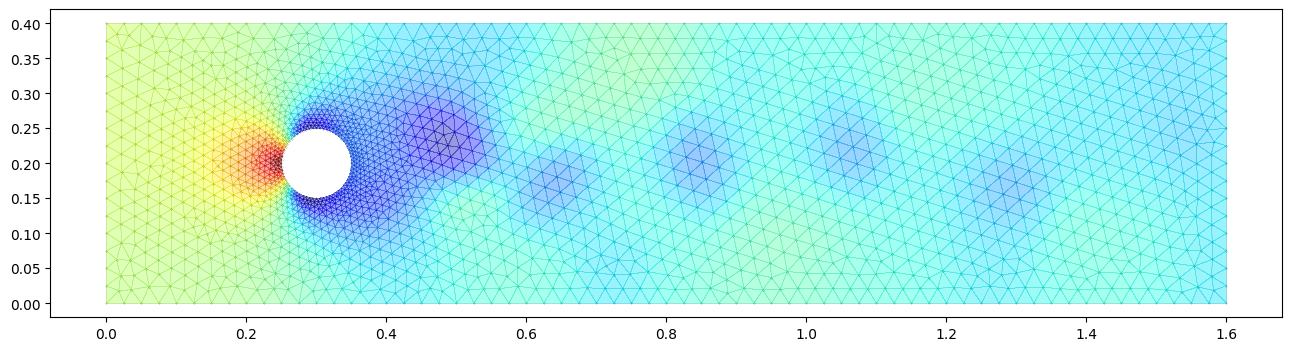

In [5]:
visulise_data(data_path)

## 3. Data statistics

In [6]:
import glob
from natsort import natsorted

In [7]:
# Make it a task
def get_mean_std(data_folder_path):
    data_list = []

    file_path = os.path.join(data_folder_path, "data_*.npy")
    file_names = glob.glob(file_path)
    file_names = natsorted(file_names)

    for file_name in file_names:
        data = load_data(file_name)
        data_list.append(data.get("field_node"))

    data = np.concatenate(data_list, axis=0)

    mean = np.mean(data, axis=0, keepdims=True)
    std = np.std(data, axis=0, keepdims=True)

    return mean, std


In [8]:
mean, std = get_mean_std("./elec-70127-fno/data/train/")

In [ ]:
from scipy.interpolate import griddata


def get_grid_and_mask(data):
    """
    Interpolate unstructured mesh data onto a regular grid using cubic interpolation.
    Matches the starter code exactly (griddata method='cubic').
    Cubic (C2 smooth) is more accurate than linear (C0) at boundary regions.
    """
    r = 0.05
    x_center = 0.3
    y_center = 0.2

    grid_num_x = 320
    grid_num_y = 80

    coord = data.get("coord")
    field_node = data.get("field_node")

    x_min, x_max = min(coord[:, 0]), max(coord[:, 0])
    y_min, y_max = min(coord[:, 1]), max(coord[:, 1])

    x_coord, y_coord = np.meshgrid(
        np.linspace(x_min, x_max, grid_num_x),
        np.linspace(y_min, y_max, grid_num_y)
    )

    x_coord, y_coord = x_coord.flatten(), y_coord.flatten()

    # calculate mask
    dis_from_center = np.sqrt((x_coord - x_center)**2 + (y_coord - y_center)**2)
    mask = dis_from_center <= r

    grid_data = []
    num_dim = field_node.shape[1]
    for i in range(num_dim):
        grid_data_i = griddata(
            coord, field_node[:, i], (x_coord, y_coord), method='cubic'
        )

        grid_data_i[mask] = 0
        grid_data_i = np.nan_to_num(grid_data_i, nan=0.0)
        grid_data_i = grid_data_i.reshape(grid_num_y, grid_num_x)
        grid_data.append(grid_data_i)

    grid_data = np.stack(grid_data, axis=0)
    mask_grid = mask.reshape(1, grid_num_y, grid_num_x)

    return grid_data, mask_grid

In [ ]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import multiprocessing


def _process_one_file(args):
    """Worker function for parallel post-processing."""
    file_name, save_dir = args
    data = np.load(file_name, allow_pickle=True).item()
    grid_data, mask = get_grid_and_mask(data)
    data["field_conv"] = grid_data
    data["mask"] = mask

    if save_dir is None:
        np.save(file_name, data)
    else:
        base_name = os.path.basename(file_name)
        np.save(os.path.join(save_dir, base_name), data)
    return True


def post_process(dataset_dir, save_dir=None, n_workers=None, force=False):
    """
    Parallel post-processing: interpolate mesh -> grid for all .npy files.
    Uses griddata(method='cubic') matching the starter code.
    ThreadPoolExecutor with all CPU cores — griddata's C code releases the GIL.
    """
    file_names = glob.glob(os.path.join(dataset_dir, "data_*.npy"))
    file_names = natsorted(file_names)

    # Skip if already processed (unless force=True)
    if save_dir is not None and not force:
        existing = glob.glob(os.path.join(save_dir, "data_*.npy"))
        if len(existing) >= len(file_names):
            print(f"Skipping {save_dir} -- already processed ({len(existing)} files). Use force=True to reprocess.")
            return

    os.makedirs(save_dir, exist_ok=True) if save_dir else None

    if n_workers is None:
        n_workers = multiprocessing.cpu_count()

    args_list = [(f, save_dir) for f in file_names]

    print(f"Processing {len(file_names)} files with {n_workers} threads (cubic interpolation)...")
    # ThreadPoolExecutor works here because griddata's C code (Qhull, CloughTocher)
    # releases the GIL. ProcessPoolExecutor crashes on Windows Jupyter (spawn + pickle).
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        list(tqdm(executor.map(_process_one_file, args_list),
                  total=len(file_names), desc="Processing files"))

In [ ]:
post_process(dataset_dir="./elec-70127-fno/data/train/", save_dir="./working/train", force=False)

In [ ]:
post_process(dataset_dir="./elec-70127-fno/data/test/", save_dir="./working/test", force=False)

In [ ]:
post_process(dataset_dir="./elec-70127-fno/data/val_task3/", save_dir="./working/val_task3", force=False)

In [14]:
data_root = "./working/"

(3, 80, 320)


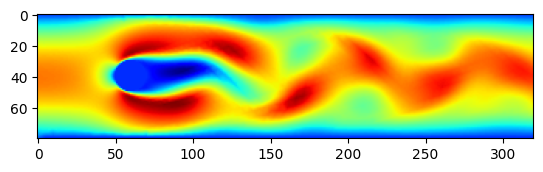

In [15]:
data = load_data(data_root + "train/data_02005.npy")

grid_data = data["field_conv"]
print(grid_data.shape)
plt.imshow(grid_data[0], cmap="jet")
plt.show()

# Subtask 02 - Dataset construction and Data Loading

In [16]:
import torch
from torch.utils.data import DataLoader, Dataset
from natsort import natsorted
from scipy.interpolate import griddata

In [17]:
import glob
class CNNDataset(Dataset):
    """
    Tier 2 Dataset: adds positional encoding (x, y) and cylinder mask as extra input channels.
    
    Positional encoding helps the FNO learn boundary effects (FFT assumes periodicity,
    but the domain has inlet/outlet/wall boundaries). The cylinder mask provides explicit
    geometry information to the model.
    
    Input shape: (x1, x2, t, 6) where channels = [vel_x, vel_y, pressure, x_pos, y_pos, mask]
    Output shape: (x1, x2, t, 3) where channels = [vel_x, vel_y, pressure]
    """

    def __init__(self, dataset_dir=None, t_dim=10, transform=None, target_transform=None):
        self.t_dim = t_dim
        self.transform = transform
        self.target_transform = target_transform

        self.file_names = glob.glob(os.path.join(dataset_dir, "data_*.npy"))
        self.file_names = natsorted(self.file_names)

    def __len__(self):
        return len(self.file_names) // (2 * self.t_dim)

    def load_data(self, data_path):
        data = np.load(data_path, allow_pickle=True).item()
        return data

    def __getitem__(self, idx):
        start_idx = idx * 2 * self.t_dim

        # Load input frames
        in_list = []
        mask = None
        for i in range(self.t_dim):
            data = self.load_data(self.file_names[start_idx + i])
            in_list.append(data.get("field_conv"))  # (3, 80, 320)
            if mask is None:
                mask = data.get("mask")  # (1, 80, 320)

        # Load output frames
        out_list = []
        for i in range(self.t_dim):
            data = self.load_data(self.file_names[start_idx + self.t_dim + i])
            out_list.append(data.get("field_conv"))

        # Stack: (3, 80, 320, 10)
        in_data = np.stack(in_list, axis=-1)
        out_data = np.stack(out_list, axis=-1)

        # Apply normalisation transforms (on channel-first physics data)
        if self.transform:
            in_data = self.transform(in_data)
        if self.target_transform:
            out_data = self.target_transform(out_data)

        # Permute physics channels to (80, 320, 10, 3)
        if isinstance(in_data, torch.Tensor):
            in_data = in_data.permute(1, 2, 3, 0)
            out_data = out_data.permute(1, 2, 3, 0)
        else:
            in_data = np.transpose(in_data, (1, 2, 3, 0))
            out_data = np.transpose(out_data, (1, 2, 3, 0))

        # Generate positional encoding grids (normalised to [0, 1])
        H, W, T = 80, 320, self.t_dim
        x_pos = np.linspace(0, 1, W).reshape(1, W, 1)
        y_pos = np.linspace(0, 1, H).reshape(H, 1, 1)
        x_pos = np.broadcast_to(x_pos, (H, W, T)).copy()
        y_pos = np.broadcast_to(y_pos, (H, W, T)).copy()

        # Broadcast mask: (1, 80, 320) -> (80, 320, T)
        mask_t = np.broadcast_to(mask[0, :, :, np.newaxis], (H, W, T)).copy()

        # Convert to tensors and concatenate as extra channels
        x_pos_t = torch.from_numpy(x_pos).float().unsqueeze(-1)      # (80, 320, 10, 1)
        y_pos_t = torch.from_numpy(y_pos).float().unsqueeze(-1)      # (80, 320, 10, 1)
        mask_t_t = torch.from_numpy(mask_t).float().unsqueeze(-1)    # (80, 320, 10, 1)

        if isinstance(in_data, torch.Tensor):
            in_data = torch.cat([in_data, x_pos_t, y_pos_t, mask_t_t], dim=-1)  # (80, 320, 10, 6)
        else:
            in_data = torch.from_numpy(in_data).float()
            in_data = torch.cat([in_data, x_pos_t, y_pos_t, mask_t_t], dim=-1)

        if not isinstance(out_data, torch.Tensor):
            out_data = torch.from_numpy(out_data).float()

        return in_data, out_data

In [18]:
dataset_dir = f"{data_root}/test/"
print(dataset_dir)

dataset = CNNDataset(dataset_dir)
print(len(dataset))

idx = 20
sample, target = dataset[idx]
print(sample.shape, target.shape)

./working//test/
25
torch.Size([80, 320, 10, 6]) torch.Size([80, 320, 10, 3])


## 2. Data Transformation

In [19]:
class Normalise:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, data):
        data = (data - self.mean) / self.std
        return data


class ToFloatTransform:
    def __init__(self, scale=True):
        return

    def __call__(self, data):
        data = torch.from_numpy(data).float()
        return data


class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, data):
        for transform in self.transforms:
            data = transform(data)
        return data

In [20]:
transform = Compose([
    Normalise(mean = mean.reshape(-1, 1, 1, 1),
              std = std.reshape(-1, 1, 1, 1)),
    ToFloatTransform(),
])

dataset = CNNDataset(dataset_dir = dataset_dir, transform=transform, target_transform=transform)

idx = 0
data_in, target = dataset[idx]

conv_in = data_in
print(conv_in.shape)

torch.Size([80, 320, 10, 6])


## 3. Data Loader

In [21]:
Loader = DataLoader(dataset=dataset, num_workers=0, batch_size=16, pin_memory=True)

# Subtask 03 - FNO

![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F24644801%2Fee12956a1e03360c33eacf463cc67094%2FWX20260202-0053412x.png?generation=1769993637576752&alt=media)

## Understanding `SpectralConv3d` Class

1. In the `class SpectralConv3d(nn.Module)` class, why we use `self.weights1, self.weights2 ...`

2. Why there is a 'self.scale = (1 / (in_channels * out_channels))` in the code? what is the purpose of this line?

3. What is the line `torch.einsum("bixyz,ioxyz->boxyz", input, weights)` doing here? Could you explain it? Could you also give a pytorch implementation with out einsum doing the same thing (porvide demo in the code cell below)? Why we want to use einsum?

4. Try to go through the `forward` methods, annotate this methods line by line explaining the purpose of each line.

## Your Answers here:
1.
...

In [22]:
# =============================================================================
# Tier 2 Architecture — Fixed fundamentals:
# - torch.randn init (proper variance for complex weights)
# - Residual connections across Fourier layers (F-FNO, Tran et al., ICLR 2023)
# - GELU activation on ALL Fourier layers (incl. last, before projection head)
# - Domain padding to reduce spectral leakage at non-periodic boundaries
# - 6 Fourier layers, 6 input channels (3 physics + x_pos + y_pos + mask)
# =============================================================================

from torch import nn
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super(SpectralConv3d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3

        # Xavier-like init for complex weights: scale ~ 1/sqrt(in_channels)
        self.scale = 1 / (in_channels ** 0.5)
        self.weights1 = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights4 = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))

    def compl_mul3d(self, input, weights):
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[-3,-2,-1])

        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, :self.modes1, :self.modes2, :self.modes3], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, -self.modes1:, :self.modes2, :self.modes3], self.weights2)
        out_ft[:, :, :self.modes1, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, :self.modes1, -self.modes2:, :self.modes3], self.weights3)
        out_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3], self.weights4)

        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x


class FNO3d(nn.Module):
    def __init__(self,
                 modes1=16,
                 modes2=10,
                 modes3=5,
                 width=48,
                 n_layers=6,
                 in_channels=6,
                 padding=8
                ):
        super(FNO3d, self).__init__()
        """
        Tier 2 FNO3d — fixed architecture:
        - Proper complex weight init (torch.randn, Xavier-like scaling)
        - Residual connections across Fourier layers for gradient flow
        - GELU activation on all layers (including last before projection)
        - Domain padding to mitigate spectral leakage at boundaries
        
        in_channels=6: [vel_x, vel_y, pressure, x_pos, y_pos, cylinder_mask]
        """
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        self.width = width
        self.n_layers = n_layers
        self.padding = padding  # Pad spatial dims to reduce boundary artifacts

        # Lift: in_channels -> width
        self.fc0 = nn.Linear(in_channels, self.width)

        # N Fourier layers
        self.spectral_convs = nn.ModuleList([
            SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
            for _ in range(n_layers)
        ])
        self.pointwise_convs = nn.ModuleList([
            nn.Conv1d(self.width, self.width, 1)
            for _ in range(n_layers)
        ])

        # Project: width -> 128 -> 3 output channels
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y, size_z = x.shape[1], x.shape[2], x.shape[3]

        # Lift to width channels
        x = self.fc0(x)
        x = x.permute(0, 4, 1, 2, 3)  # (B, width, x, y, t)

        # Pad spatial dimensions to reduce spectral leakage
        if self.padding > 0:
            # Pad x and y dims (reflect padding at boundaries)
            x = F.pad(x, [0, 0, 0, self.padding, 0, self.padding])

        # Fourier layers with residual connections
        for i in range(self.n_layers):
            x1 = self.spectral_convs[i](x)
            x2 = self.pointwise_convs[i](x.reshape(batchsize, self.width, -1))
            x2 = x2.view(batchsize, self.width, x.size(2), x.size(3), x.size(4))
            x = x + x1 + x2  # Residual: input + spectral + pointwise
            x = F.gelu(x)    # Activation on ALL layers including last

        # Remove padding
        if self.padding > 0:
            x = x[:, :, :size_x, :size_y, :]

        x = x.permute(0, 2, 3, 4, 1)  # (B, x, y, t, width)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)

        return x

In [ ]:
# Test Tier 2 model with 6 input channels + padding
model = FNO3d(modes1=16, modes2=16, modes3=5, width=48, n_layers=6, in_channels=6, padding=8)
dummy = torch.randn((4, 80, 320, 10, 6))
print(model(dummy).shape)  # Expected: torch.Size([4, 80, 320, 10, 3])
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# =============================================================================
# Tier 2 Training — Fixed fundamentals:
# - Gradient clipping (stabilises training with residual connections)
# - Gradient accumulation (effective batch size = micro_bs * accum_steps)
# - H1 Sobolev loss, noise injection (physics only), tqdm, best model saving
# =============================================================================

import matplotlib.pyplot as plt
from tqdm import tqdm


def get_run_dir(version="v2"):
    """Create a new numbered run directory: ./runs/vX/run_NNN/"""
    base = f"./runs/{version}"
    os.makedirs(base, exist_ok=True)
    existing = [d for d in os.listdir(base) if d.startswith("run_")]
    run_num = len(existing) + 1
    run_dir = os.path.join(base, f"run_{run_num:03d}")
    os.makedirs(run_dir, exist_ok=True)
    print(f"Saving to: {run_dir}")
    return run_dir


def get_latest_run_dir(version="v2"):
    """Find the latest run directory for a given version."""
    base = f"./runs/{version}"
    if not os.path.exists(base):
        return "."
    existing = sorted([d for d in os.listdir(base) if d.startswith("run_")])
    if not existing:
        return "."
    return os.path.join(base, existing[-1])


class H1SobolevLoss(torch.nn.Module):
    """H1 Sobolev loss with spatial gradient penalty (Sobolev Training, 2024)."""
    def __init__(self, alpha=0.1):
        super().__init__()
        self.alpha = alpha

    def _rel_l2(self, a, b):
        return torch.norm(a - b) / (torch.norm(b) + 1e-8)

    def forward(self, pred, target):
        l2 = self._rel_l2(pred, target)
        dx_pred = pred[:, 1:, :, :, :] - pred[:, :-1, :, :, :]
        dx_target = target[:, 1:, :, :, :] - target[:, :-1, :, :, :]
        dy_pred = pred[:, :, 1:, :, :] - pred[:, :, :-1, :, :]
        dy_target = target[:, :, 1:, :, :] - target[:, :, :-1, :, :]
        grad_loss = self._rel_l2(dx_pred, dx_target) + self._rel_l2(dy_pred, dy_target)
        return l2 + self.alpha * grad_loss


def train_one_epoch(model, loader, optimizer, criterion,
                    noise_std=0.01, max_grad_norm=1.0, accum_steps=2):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="Training", leave=False)):
        in_data, out_data = batch
        in_data = in_data.to(device, non_blocking=True)
        out_data = out_data.to(device, non_blocking=True)

        # Noise injection on physics channels only (first 3)
        noise = torch.zeros_like(in_data)
        noise[..., :3] = noise_std * torch.randn_like(in_data[..., :3])
        in_data = in_data + noise

        pred = model(in_data)
        loss = criterion(pred, out_data) / accum_steps

        loss.backward()

        # Step after gradient accumulation
        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps

    return total_loss / len(loader)


def test_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing", leave=False):
            in_data, out_data = batch
            in_data = in_data.to(device, non_blocking=True)
            out_data = out_data.to(device, non_blocking=True)
            pred = model(in_data)
            loss = criterion(pred, out_data)
            total_loss += loss.item()
    return total_loss / len(loader)


def plot_losses(train_losses, test_losses, test_epochs, run_dir,
                title="Training & Test Loss (v2 - Tier 2)"):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", alpha=0.8)
    if test_losses:
        ax.plot(test_epochs, test_losses, 'o-', label="Test Loss", alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")
    fig.tight_layout()
    fig.savefig(os.path.join(run_dir, "loss_plot.png"), dpi=150)
    plt.show()
    plt.close(fig)


def train(n_epochs, model, optimizer, scheduler, loader_train, loader_test,
          run_dir, accum_steps=2):
    criterion = H1SobolevLoss(alpha=0.1)
    model = model.to(device)

    best_test_loss = float("inf")
    train_losses, test_losses, test_epochs = [], [], []

    for epoch in tqdm(range(n_epochs), desc="Epochs"):
        loss = train_one_epoch(
            model, loader_train, optimizer, criterion,
            noise_std=0.01, max_grad_norm=1.0, accum_steps=accum_steps)
        train_losses.append(loss)
        scheduler.step()

        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}, Loss {loss:.6f}, LR {lr:.2e}")

        if (epoch + 1) % 5 == 0:
            test_loss = test_one_epoch(model, loader_test, criterion)
            test_losses.append(test_loss)
            test_epochs.append(epoch + 1)
            print(f"  Test Loss: {test_loss:.6f}")

            if test_loss < best_test_loss:
                best_test_loss = test_loss
                torch.save(model.state_dict(),
                          os.path.join(run_dir, "best_model.pth"))
                print(f"  >> New best ({test_loss:.6f})")

            torch.save(model.state_dict(),
                      os.path.join(run_dir, f"epoch_{epoch+1}.pth"))

    plot_losses(train_losses, test_losses, test_epochs, run_dir)
    print(f"Training complete. Best test loss: {best_test_loss:.6f}, saved in {run_dir}")
    return run_dir

## Model Training and Tuning

Key Considerations:

What is the role of modes1, modes2, and modes3?
> These parameters define the number of Fourier modes retained in each spatial dimension, controlling the spectral resolution of the model.

What loss function did you use to train the model?
> Specify the loss function(s) experimented with and justify the choice in terms of stability, convergence, and accuracy.

Model Tuning and Optimization Log:

Provide a concise summary of your model tuning process, including:
* Alterations made to the baseline model to improve performance.
* Hyperparameter adjustments and their impact.
* The most effective modification that led to the best overall results.

Clearly document your reasoning behind each change to demonstrate an iterative, data-driven approach to model optimization.

In [ ]:
# Tier 2 Training Configuration
n_epochs = 300
lr = 1e-3
bs = 6           # micro-batch size
accum_steps = 2  # effective batch size = 6 * 2 = 12

model = FNO3d(modes1=16, modes2=16, modes3=5, width=48, n_layers=6, in_channels=6, padding=8)

train_set = CNNDataset(
    dataset_dir=f"{data_root}/train/",
    transform=transform, target_transform=transform)
test_set = CNNDataset(
    dataset_dir=f"{data_root}/test/",
    transform=transform, target_transform=transform)

loader_train = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=0, pin_memory=True)
loader_test = DataLoader(test_set, batch_size=bs, num_workers=0, pin_memory=True)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# Warmup (10 epochs linear ramp) + Cosine annealing
warmup_epochs = 10
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0,
    total_iters=warmup_epochs)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_epochs - warmup_epochs, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs])

run_dir = get_run_dir("v2")
current_run_dir = train(n_epochs, model, optimizer, scheduler,
                        loader_train, loader_test, run_dir, accum_steps)

In [26]:
def load_model(model, weight_path, strict=False):
    """
    Loads pre-trained weights into a PyTorch model from a given file path.

    Args:
        model (torch.nn.Module): The PyTorch model.
        weight_path (str): File path to the pre-trained model weights.

    Returns:
        torch.nn.Module: The model with loaded weights.
    """
    try:
        model.load_state_dict(torch.load(weight_path), strict=strict)
    except RuntimeError:
        state_dict = torch.load(weight_path, map_location=device)
        model.load_state_dict(state_dict, strict=strict)
    return model


def denormalise(data, mean, std):
    return data * std + mean

def normalise(data, mean, std):
    return (data - mean) / std

def calc_norm_error(pred, truth, ord=2):
    """
    Compute the relative error of two input. input are supposed to have
    shape of (channel, height, width). Other shape might work but please
    be careful and aware of what you are doing.

    pred: The prediction output by model.
    truth: The ground truth against which error are measured.
    ord: the order of norm.
    """
    pred, truth = [vec.flatten() for vec in [pred, truth]]
    nume = torch.linalg.norm((pred - truth), ord=ord)
    deno = torch.linalg.norm(truth, ord=ord)
    return nume / deno

def calculate_error_and_inference(dataloader, model, mean, std):
    """
    Global Relative L2 Error: ||pred_all - truth_all|| / ||truth_all||
    Accumulates numerator and denominator norms across all batches,
    then computes a single global metric (consistent with Kaggle scoring).
    """
    model.to(device)
    model.eval()
    total_num_sq = 0.0   # sum of ||pred_i - truth_i||^2
    total_den_sq = 0.0   # sum of ||truth_i||^2
    pred_list = []
    ground_list = []
    with torch.no_grad():
        for batch in dataloader:
            data_in, target = batch
            data_in, target = data_in.to(device), target.to(device)
            pred = model(data_in)
            pred, target = denormalise(pred, mean, std), denormalise(target, mean, std)
            pred_list.append(pred.detach().cpu().numpy())
            ground_list.append(target.detach().cpu().numpy())
            # Accumulate squared norms for global metric
            diff = (pred - target).flatten()
            truth_flat = target.flatten()
            total_num_sq += torch.dot(diff, diff).item()
            total_den_sq += torch.dot(truth_flat, truth_flat).item()
    # Global Relative L2 = sqrt(sum ||diff||^2) / sqrt(sum ||truth||^2)
    error = (total_num_sq ** 0.5) / (total_den_sq ** 0.5 + 1e-8)
    return error, pred_list, ground_list

In [ ]:
# Evaluate Tier 2 model (best on test set)
model = FNO3d(modes1=16, modes2=16, modes3=5, width=48, n_layers=6, in_channels=6, padding=8)

run_dir = current_run_dir if 'current_run_dir' in dir() else get_latest_run_dir("v2")
weight_path = os.path.join(run_dir, "best_model.pth")
if not os.path.exists(weight_path):
    weight_path = "./best_model.pth" if os.path.exists("./best_model.pth") else "./epoch_200.pth"
model = load_model(model, weight_path)
print(f"Loaded weights from: {weight_path}")

dataset_test = CNNDataset(
    dataset_dir=f"{data_root}/test/",
    transform=transform, target_transform=transform)
test_loader = DataLoader(dataset_test, batch_size=1, num_workers=0, pin_memory=True)

error, pred, ground = calculate_error_and_inference(
    test_loader, model,
    mean=torch.tensor(mean.reshape(1, 1, 1, 1, -1)).to(device),
    std=torch.tensor(std.reshape(1, 1, 1, 1, -1)).to(device),
)
print(f"Relative L2 Error (Tier 2): {error:.6f}")

In [28]:
def pred_to_df(data):
    reshaped = data.reshape(-1, 3)
    df = pd.DataFrame(reshaped, columns=['Feature_1', 'Feature_2', 'Feature_3'])
    df.index.name = "ROW_ID"
    return df

In [29]:
# Val_task3 inference with positional encoding + mask (Tier 2)
file_dir = f"{data_root}/val_task3/"
file_names = glob.glob(os.path.join(file_dir, "data_*.npy"))
file_names = natsorted(file_names)

in_list = []
mask = None
for i in range(len(file_names)):
    data_i = load_data(file_names[i])
    field = data_i.get("field_conv")
    if mask is None:
        mask = data_i.get("mask")  # (1, 80, 320)
    field = normalise(field, mean=mean.reshape(-1, 1, 1), std=std.reshape(-1, 1, 1))
    in_list.append(field)

# Stack and permute: (3, 80, 320, 10) -> (80, 320, 10, 3)
in_data = np.stack(in_list, axis=-1)  # (3, 80, 320, 10)
in_data = np.transpose(in_data, (1, 2, 3, 0))  # (80, 320, 10, 3)

# Add positional encoding + mask channels
H, W, T = 80, 320, len(file_names)
x_pos = np.linspace(0, 1, W).reshape(1, W, 1)
y_pos = np.linspace(0, 1, H).reshape(H, 1, 1)
x_pos = np.broadcast_to(x_pos, (H, W, T)).copy()
y_pos = np.broadcast_to(y_pos, (H, W, T)).copy()
mask_t = np.broadcast_to(mask[0, :, :, np.newaxis], (H, W, T)).copy()

# Concatenate: (80, 320, 10, 6)
in_data = np.concatenate([
    in_data,
    x_pos[..., np.newaxis],
    y_pos[..., np.newaxis],
    mask_t[..., np.newaxis]
], axis=-1)

in_data = torch.tensor(in_data).unsqueeze(0).float().to(device)
print(in_data.shape)  # Expected: (1, 80, 320, 10, 6)

model.to(device)
model.eval()
with torch.no_grad():
    pred = model(in_data).detach().cpu().numpy()
    pred = denormalise(pred, mean, std)
print(pred.shape)

torch.Size([1, 80, 320, 10, 6])
(1, 80, 320, 10, 3)


In [30]:
pred = np.stack(pred, axis=0)
print(pred.shape)

(1, 80, 320, 10, 3)


In [31]:
import pandas as pd
print(pred.shape)
# save file for submission in run directory
pred_1 = np.stack(pred, axis=0)
run_dir = current_run_dir if 'current_run_dir' in dir() else get_latest_run_dir("v2")
np.save(os.path.join(run_dir, "pred_1.npy"), pred_1)
pred_to_df(pred_1).to_csv(os.path.join(run_dir, "submission.csv"), index=True)
print(f"Submission saved to: {os.path.join(run_dir, 'submission.csv')}")

(1, 80, 320, 10, 3)
Submission saved to: ./runs/v2\run_011\submission.csv


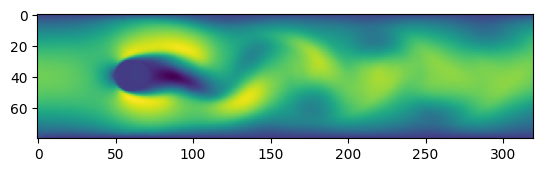

In [32]:
import matplotlib.tri as tri
cmap = "jet"
zeta = 10

coord = data["coord"]
face = data["cell_node_list"]

left, right = min(coord[:, 0]), max(coord[:, 0])
bottom, top = min(coord[:, 1]), max(coord[:, 1])
idx = 9

value = pred[0, :, :, idx, 0]
plt.imshow(value)

## Generative AI Usage Log

Document your usage of generative AI.

### Case 1:

- **Tool Used:**  

- **Question / Context:**  

- **Prompt / Process:**  

- **How You Used the Output:**

### Case 2:

...


